<a href="https://colab.research.google.com/github/Ravanan07/Online-food-delivery-Analysis/blob/main/Food_delivery_time_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [2]:
df = pd.read_csv('/content/sample_data/Food_Delivery_Times.csv')
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [3]:
df.shape

(1000, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [5]:
df.isna().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


In [6]:
#Filling Null values by using mode(Categorical Values)
df['Weather'] = df['Weather'].fillna(df['Weather'].mode()[0])
df['Traffic_Level'] = df['Traffic_Level'].fillna(df['Traffic_Level'].mode()[0])
df['Time_of_Day'] = df['Time_of_Day'].fillna(df['Time_of_Day'].mode()[0])

#Filling Null values by using median(Numerical Values)
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].median())

In [7]:
df.isna().sum()

,0
Order_ID,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


In [8]:
#OneHotEncoding
df_encoded = pd.get_dummies(df,columns=['Weather','Time_of_Day','Vehicle_Type'],dtype=int)
df_encoded.head()

,Order_ID,Distance_km,Traffic_Level,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Vehicle_Type_Scooter
0,522,7.93,Low,12,1.0,43,0,0,0,0,1,1,0,0,0,0,0,1
1,738,16.42,Medium,20,2.0,84,1,0,0,0,0,0,1,0,0,1,0,0
2,741,9.52,Low,28,1.0,59,0,1,0,0,0,0,0,0,1,0,0,1
3,661,7.44,Medium,5,1.0,37,0,0,1,0,0,1,0,0,0,0,0,1
4,412,19.03,Low,16,5.0,68,1,0,0,0,0,0,0,1,0,1,0,0


In [9]:
#LabelEncoding manually using Mapping method
traffic_mapping = {'Low' : 0, 'Medium' : 1, 'High' : 2} #Assign int values to the name using Dict
df['Traffic_Level'] = df['Traffic_Level'].map(traffic_mapping)
df_encoded['Traffic_Level'] = df['Traffic_Level']

In [10]:
df_encoded.head()

,Order_ID,Distance_km,Traffic_Level,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Vehicle_Type_Scooter
0,522,7.93,0,12,1.0,43,0,0,0,0,1,1,0,0,0,0,0,1
1,738,16.42,1,20,2.0,84,1,0,0,0,0,0,1,0,0,1,0,0
2,741,9.52,0,28,1.0,59,0,1,0,0,0,0,0,0,1,0,0,1
3,661,7.44,1,5,1.0,37,0,0,1,0,0,1,0,0,0,0,0,1
4,412,19.03,0,16,5.0,68,1,0,0,0,0,0,0,1,0,1,0,0


In [11]:
df_final = df_encoded.drop(columns=['Order_ID'])

In [12]:
x = df_final.drop(columns=['Delivery_Time_min'])
y = df_final['Delivery_Time_min']

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error


x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.3,random_state=42)
models = {'Linear Regression':LinearRegression(),
          'Random Forest':RandomForestRegressor(),
          'Decision Tree':DecisionTreeRegressor(),
          'Gradient Boosting':GradientBoostingRegressor()}

comparison_results = [] # Initialize a list to store results

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    #print(f"{name} MAE: {mae}\t\t\tR2 Score:{r2}")

    # Append results as a dictionary to the list
    comparison_results.append({'Model Name': name, 'MAE': mae, 'R2 Score': r2})

# Create the comparison_df after the loop
comparison_df = pd.DataFrame(comparison_results)
print("\nCompare diff Models:\n")
print(comparison_df)


Compare diff Models:

          Model Name        MAE  R2 Score
0  Linear Regression   6.016510  0.832367
1      Random Forest   6.804933  0.805287
2      Decision Tree  10.633333  0.505052
3  Gradient Boosting   6.239134  0.822371


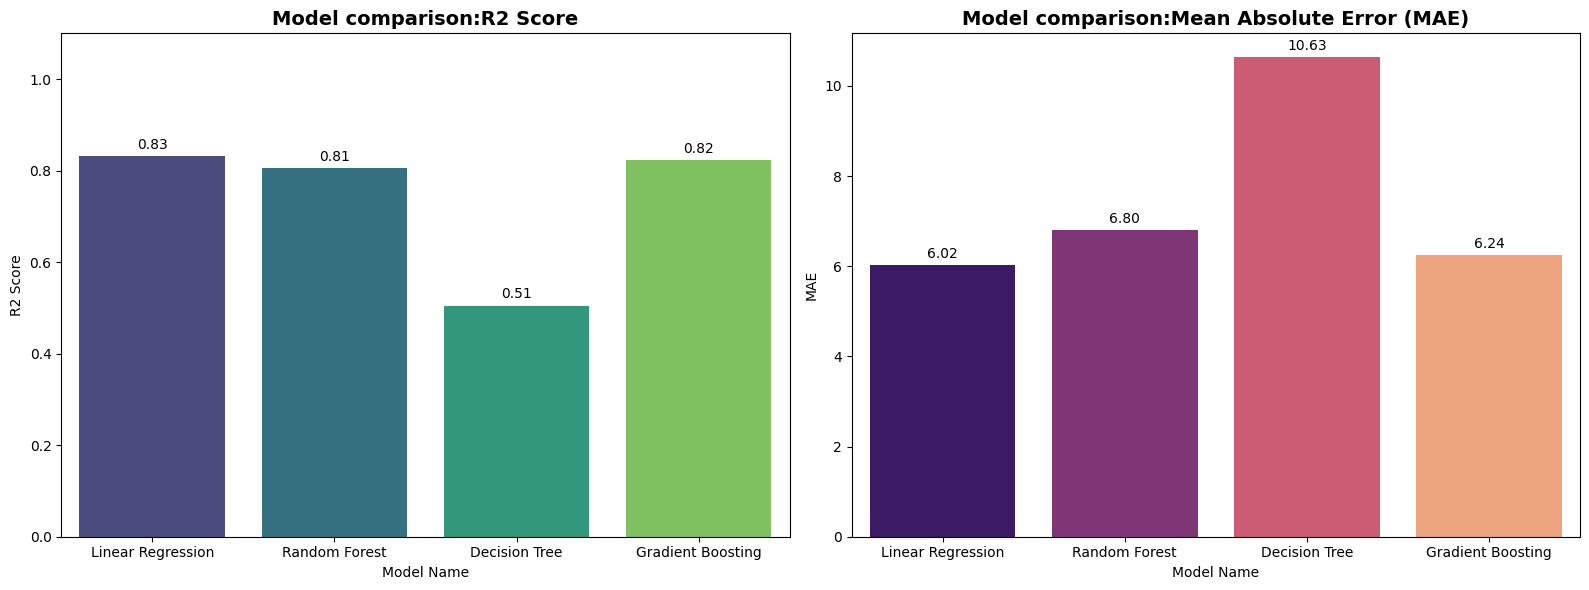

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

#R2 Score comparison plot
sns.barplot(x='Model Name', y='R2 Score', data=comparison_df, palette='viridis', hue='Model Name', legend=False, ax=ax1)
ax1.set_title('Model comparison:R2 Score',fontsize=14,fontweight='bold')
ax1.set_ylim(0, 1.1)
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.2f', padding=3)

#Mean Avsolute Error comparison plot
sns.barplot(x='Model Name', y='MAE', data=comparison_df, palette='magma', hue='Model Name', legend=False, ax=ax2)
ax2.set_title('Model comparison:Mean Absolute Error (MAE)',fontsize=14,fontweight='bold')

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
#plt.figure(figsize=(8,5))
#sns.histplot(df_final['Delivery_Time_min'],kde=True, color='blue')
#plt.title('Distribution of Delivery Time')
#plt.show()

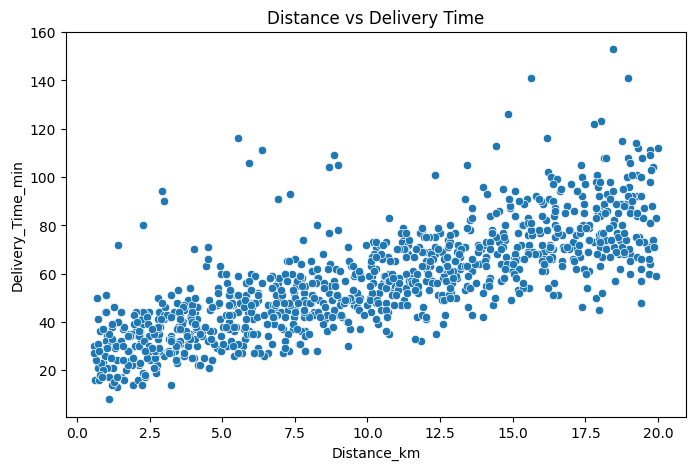

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Distance_km', y='Delivery_Time_min', data=df_final)
plt.title('Distance vs Delivery Time')
plt.show()

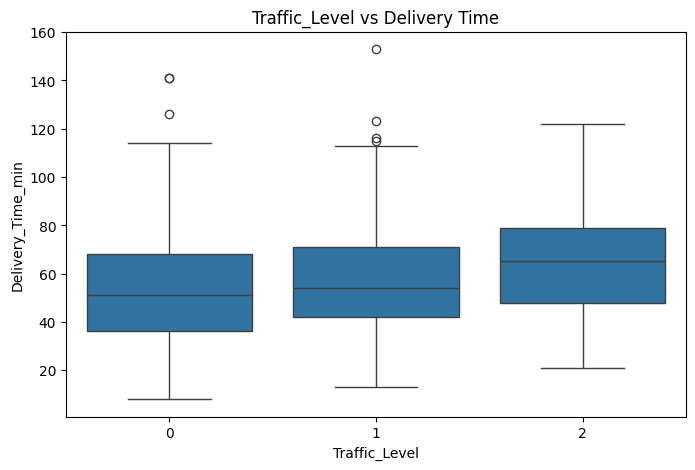

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Traffic_Level', y='Delivery_Time_min', data=df_final)
plt.title('Traffic_Level vs Delivery Time')
plt.show()

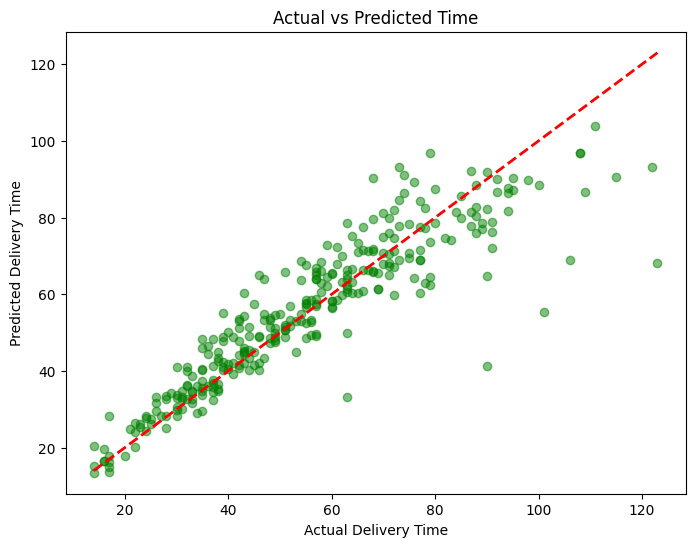

In [19]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'r--',lw=2)
plt.xlabel('Actual Delivery Time')
plt.ylabel('Predicted Delivery Time')
plt.title('Actual vs Predicted Time')
plt.show()

In [20]:
import pickle


linear_regression_model = models['Linear Regression']

with open('model.pkl','wb') as f:
  pickle.dump(linear_regression_model,f)

In [21]:
df_final.to_csv('df_final.csv',index=False)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Distance_km             1000 non-null   float64
 1   Traffic_Level           1000 non-null   int64  
 2   Preparation_Time_min    1000 non-null   int64  
 3   Courier_Experience_yrs  1000 non-null   float64
 4   Delivery_Time_min       1000 non-null   int64  
 5   Weather_Clear           1000 non-null   int64  
 6   Weather_Foggy           1000 non-null   int64  
 7   Weather_Rainy           1000 non-null   int64  
 8   Weather_Snowy           1000 non-null   int64  
 9   Weather_Windy           1000 non-null   int64  
 10  Time_of_Day_Afternoon   1000 non-null   int64  
 11  Time_of_Day_Evening     1000 non-null   int64  
 12  Time_of_Day_Morning     1000 non-null   int64  
 13  Time_of_Day_Night       1000 non-null   int64  
 14  Vehicle_Type_Bike       1000 non-null   i

In [22]:
sample = pd.DataFrame({
    "Distance_km": [5.0],
    "Traffic_Level": [1],
    "Preparation_Time_min": [20],
    "Courier_Experience_yrs": [2.0], # Assuming a default/median value
    "Weather_Clear": [0],
    "Weather_Foggy": [1],
    "Weather_Rainy": [0],
    "Weather_Snowy": [0],
    "Weather_Windy": [0], # Example: Assuming Windy
    "Time_of_Day_Afternoon": [0],
    "Time_of_Day_Evening": [0],
    "Time_of_Day_Morning": [1], # Example: Assuming Morning
    "Time_of_Day_Night": [0],
    "Vehicle_Type_Bike": [0],
    "Vehicle_Type_Car": [0],
    "Vehicle_Type_Scooter": [1] # Example: Assuming Scooter
})


predicted_time = model.predict(sample)
print("Predicted Delivery Time", predicted_time[0])

Predicted Delivery Time 47.3966609303113
